# 🧪 Tutorial PennyLane: Fundamentos e Simuladores Avançados

Este tutorial apresenta o ecossistema PennyLane, focando na criação de circuitos quânticos, medições e técnicas avançadas de simulação usando **Statevector** e **Tensor Networks**.

---

## 1. Configuração Inicial

O PennyLane utiliza uma versão customizada do NumPy que permite a diferenciação automática, essencial para Quantum Machine Learning.

In [149]:
import pennylane as qml
from pennylane import numpy as np
from pprint import pprint
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt
import atlas_mpl_style as ampl
import warnings
ampl.use_atlas_style()
plt.rcParams['font.family'] = 'DeJavu Sans'
plt.rcParams['font.serif'] = ['Times New Roman']
warnings.filterwarnings("ignore")
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 2. Construindo um Circuito (QNode)

No PennyLane, um circuito quântico é definido como uma função Python decorada por um `QNode`. Ele associa operações quânticas a um dispositivo de execução (`device`).

Probabilidades da Base Computacional: [0.5 0.  0.  0.5]


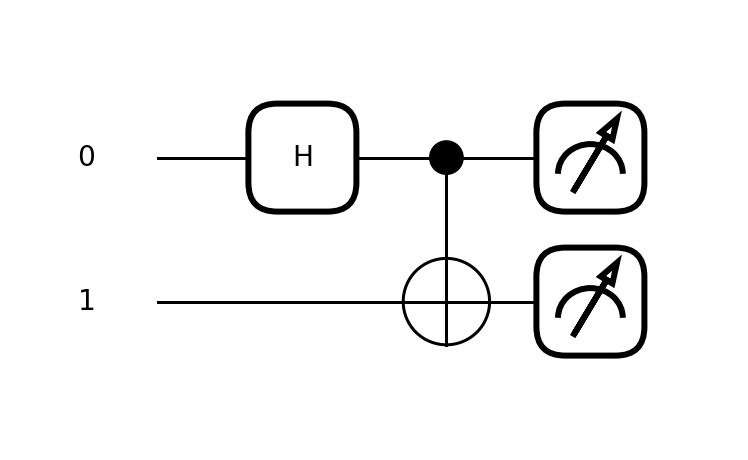

In [150]:
# 1. Definimos o dispositivo simulador
dev = qml.device("default.qubit", wires=2)

# 2. Criamos o QNode
@qml.qnode(dev)
def bell_state_circuit():
    qml.Hadamard(wires=0)
    qml.CNOT(wires=[0, 1])
    return qml.probs(wires=[0, 1])

print(f"Probabilidades da Base Computacional: {bell_state_circuit()}")

# Visualizando o circuito
qml.draw_mpl(bell_state_circuit)()
plt.show()

## 3. Tipos de Medição

Existem várias formas de extrair informação de um circuito quântico:

*   **`qml.expval(Op)`**: Valor esperado de um observável.
*   **`qml.probs(wires)`**: Distribuição de probabilidade.
*   **`qml.state()`**: O vetor de estado completo (apenas para simuladores de estado).
*   **`qml.sample(Op)`**: Resultados de medições individuais (shots).

Valor esperado (Z no wire 0): 0.8775825618903726
Probabilidades (wire 1): [0. 1.]


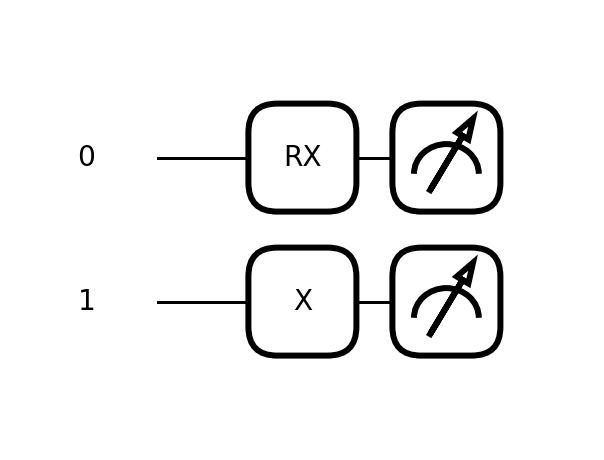

In [151]:
@qml.qnode(dev)
def measurement_demo(theta):
    qml.RX(theta, wires=0)
    qml.PauliX(wires=1)
    return qml.expval(qml.PauliZ(0)), qml.probs(wires=1)

val, p = measurement_demo(0.5)
print(f"Valor esperado (Z no wire 0): {val}")
print(f"Probabilidades (wire 1): {p}")
# Visualizando o circuito
qml.draw_mpl(measurement_demo)(0.5)
plt.show()

### 3.1 Entendendo o Porquê das Medições

No PennyLane (e computação quântica em geral), precisamos extrair informação clássica do estado quântico. Aqui explicamos o que foi usado:

*   **`qml.expval(qml.PauliZ(0))`**: Isso calcula o **valor esperado** de medir o qubit 0 na base Z. 
    - Se o qubit estiver em $|0\rangle$, o valor esperado é $+1$.
    - Se estiver em $|1\rangle$, é $-1$.
    - Se estiver em superposição $|+\rangle$, o valor esperado é $0$.
    - Aplicamos no qubit 0 (`wires=0`) porque os observáveis são locais; você define qual "fio" ou qubit deseja interrogar.
*   **`qml.probs(wires=[...])`**: Retorna as probabilidades de colapso em cada bitstring da base computacional.
    - Para 1 qubit: $[P(0), P(1)]$.
    - Para 2 qubits: $[P(00), P(01), P(10), P(11)]$.
*   **`qml.PauliZ(0)`**: Representa o operador de Pauli-Z atuando no qubit 0. É a nossa "pergunta" ao sistema: 'Qual sua projeção no eixo Z?'.

## 3.2 Exemplos: Teorema de Bell e Estado GHZ

O estado GHZ é uma generalização do estado de Bell para N qubits: $|GHZ\rangle = \frac{|0...0\rangle + |1...1\rangle}{\sqrt{2}}$. É um exemplo clássico de estado "maximalmente emaranhado".

Probs GHZ (5 qubits): [0.5 0. ] ... [0.5]


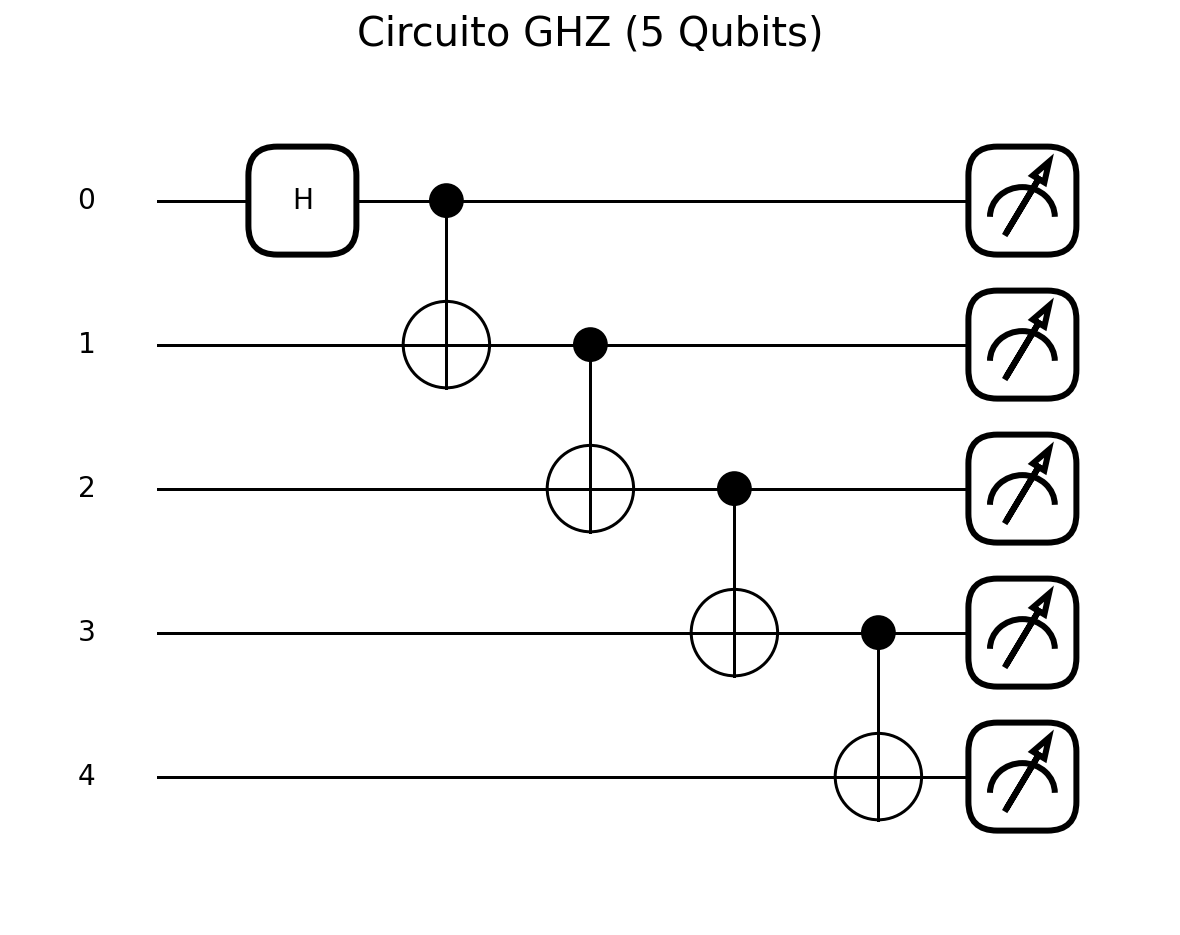

In [160]:
n_ghz = 5
dev_ghz = qml.device("default.qubit", wires=n_ghz)

@qml.qnode(dev_ghz)
def ghz_circuit():
    qml.Hadamard(wires=0)
    for i in range(n_ghz - 1):
        qml.CNOT(wires=[i, i+1])
    return qml.probs(wires=range(n_ghz))

probs = ghz_circuit()
print(f"Probs GHZ (5 qubits): {probs[:2]} ... {probs[-1:]}")

# Visualização MPL
qml.draw_mpl(ghz_circuit)()
plt.title("Circuito GHZ (5 Qubits)")
plt.show()

## 3.4 Customização: Statevector vs Tensor Networks

A simulação padrão (`default.qubit`) usa **Statevector**, onde o vetor de estado completo ($2^n$ elementos) é mantido em memória. Para circuitos com muitos qubits mas emaranhamento local (em cadeia), a abordagem de **Tensor Networks** (como Matrix Product States - MPS) é muito mais eficiente.

### Exemplo Complexo: Circuito em Cadeia 1D (Tipo MPS)
Abaixo, simulamos um circuito que aplica rotações e emaranhamento sequencial, ideal para ser representado por tensores.

Valores esperados (Variacional): [tensor(0.22211367, requires_grad=True), tensor(0.42250585, requires_grad=True), tensor(0.23917049, requires_grad=True), tensor(0.19331996, requires_grad=True), tensor(0.18191654, requires_grad=True)]


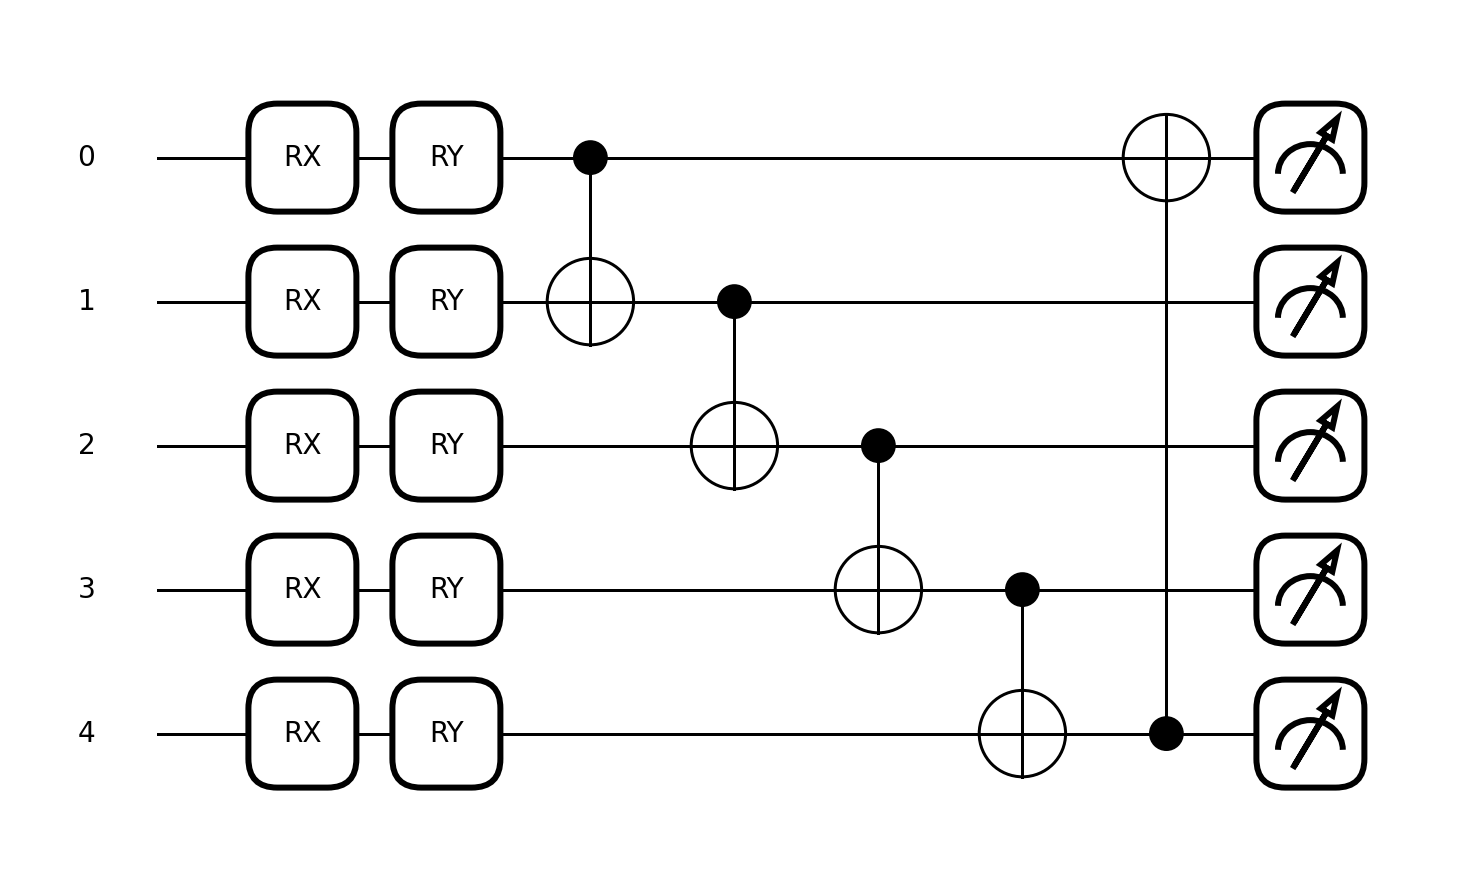

In [161]:

# Exemplo de Camada Variacional (Padrão em QML)
@qml.qnode(dev_ghz)
def variational_circuit(params):
    # Camada de Rotações variacionais
    for i in range(n_ghz):
        qml.RX(params[i, 0], wires=i)
        qml.RY(params[i, 1], wires=i)
    
    # Entalhamento em anel
    for i in range(n_ghz):
        qml.CNOT(wires=[i, (i + 1) % n_ghz])
        
    return [qml.expval(qml.PauliZ(i)) for i in range(n_ghz)]

params = np.random.random((n_ghz, 2))
print(f"Valores esperados (Variacional): {variational_circuit(params)}")
qml.draw_mpl(variational_circuit)(params)
plt.show()

## 4. Customizando a Simulação

### Statevector Simulation (`default.qubit`)
Esta é a simulação padrão, onde o estado é representado por um vetor de tamanho $2^N$. Para alta performance, recomenda-se o use do `lightning.qubit` (otimizado em C++).

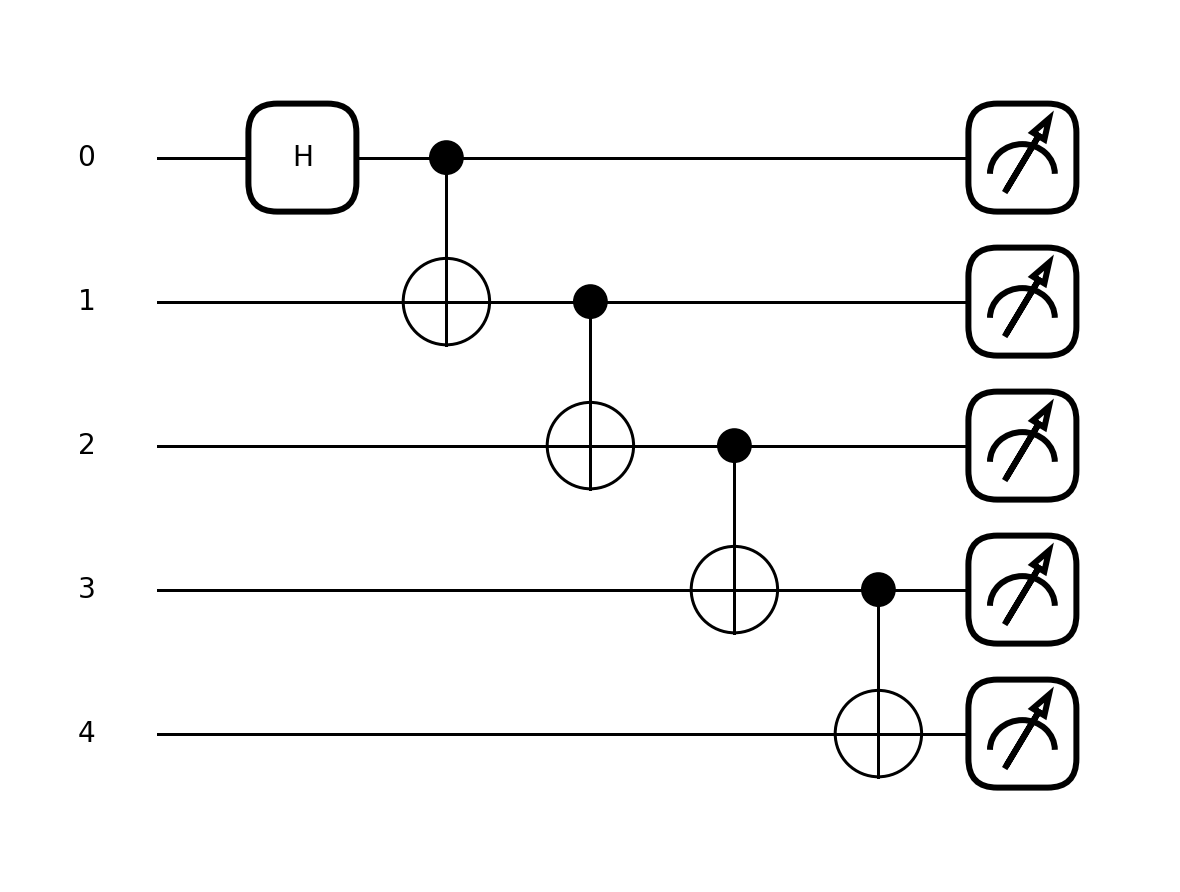

In [162]:
n_ghz = 5

# Usando o simulador Lightning para alta performance
dev_fast = qml.device("lightning.qubit", wires=n_ghz)

@qml.qnode(dev_fast)
def ghz_circuit_ideal( output_mode = 0):
    qml.Hadamard(wires=0)
    for i in range(n_ghz - 1):
        qml.CNOT(wires=[i, i+1])
    if output_mode=="probs":
        return qml.probs(wires=range(n_ghz))
    elif output_mode=="state":
        return qml.state()
    elif output_mode=="sample":
        return qml.sample()
    
qml.draw_mpl(ghz_circuit_ideal)("sample")
plt.show()

In [163]:
print(f"state vector:")
pprint(ghz_circuit_ideal("probs"))

state vector:
array([0.5, 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ,
       0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ,
       0. , 0. , 0. , 0. , 0. , 0.5])


In [164]:
print(f"probs:")
pprint(ghz_circuit_ideal("state"))

probs:
array([0.70710678+0.j, 0.        +0.j, 0.        +0.j, 0.        +0.j,
       0.        +0.j, 0.        +0.j, 0.        +0.j, 0.        +0.j,
       0.        +0.j, 0.        +0.j, 0.        +0.j, 0.        +0.j,
       0.        +0.j, 0.        +0.j, 0.        +0.j, 0.        +0.j,
       0.        +0.j, 0.        +0.j, 0.        +0.j, 0.        +0.j,
       0.        +0.j, 0.        +0.j, 0.        +0.j, 0.        +0.j,
       0.        +0.j, 0.        +0.j, 0.        +0.j, 0.        +0.j,
       0.        +0.j, 0.        +0.j, 0.        +0.j, 0.70710678+0.j])


## 6. Integração com Qiskit Aer Customizado

Podemos levar o poder do Qiskit Aer (incluindo modelos de ruído e métodos específicos) para o PennyLane através do plugin `pennylane-qiskit`. Isso permite usar o Aer como o backend de execução de um `device` do PennyLane.

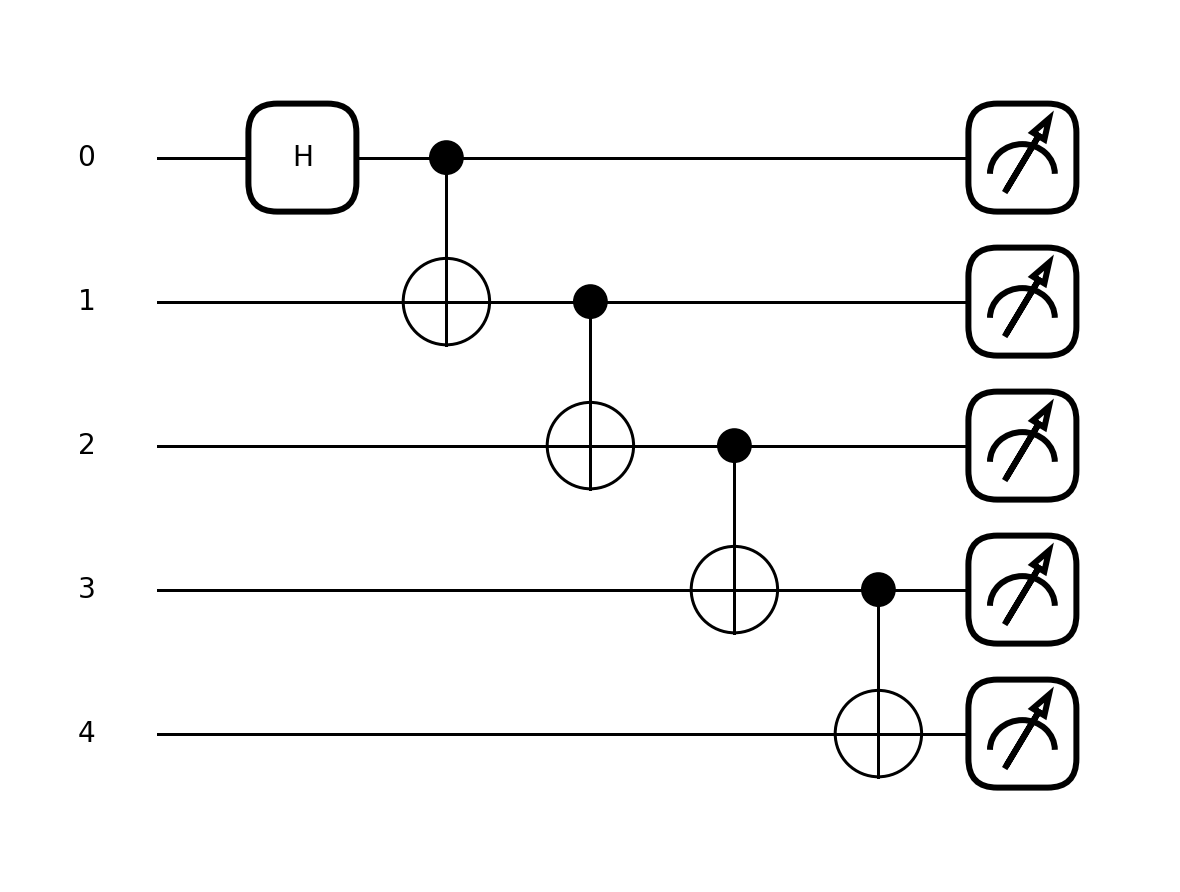

In [165]:
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, pauli_error, depolarizing_error, ReadoutError

# Para produzir counts em quase todas as bitstrings, vamos aumentar significativamente o ruído
# e adicionar erros de leitura (readout) e erros em portas CNOT.
bit_flip_p = 0.15
phase_flip_p = 0.15
depol_p_2q = 0.3
readout_p = 0.25

# 1. Definimos erro de Bit-Flip e Phase-Flip para portas de 1 qubit
bit_flip = pauli_error([('X', bit_flip_p), ('I', 1 - bit_flip_p)])
phase_flip = pauli_error([('Z', phase_flip_p), ('I', 1 - phase_flip_p)])
single_q_error = bit_flip.compose(phase_flip)

# 2. Definimos erro de despolarização para portas de 2 qubits (CNOT)
two_q_error = depolarizing_error(depol_p_2q, 2)

# 3. Definimos erro de medição (Readout Error)
# Matriz de probabilidade: P(read 0 | state 0) = 1-p, P(read 1 | state 0) = p, etc.
read_err = ReadoutError([[1 - readout_p, readout_p], [readout_p, 1 - readout_p]])

# Criamos o modelo de ruído e adicionamos os erros
noise_model = NoiseModel()
noise_model.add_all_qubit_quantum_error(single_q_error, ['h', 'u1', 'u2', 'u3'])
noise_model.add_all_qubit_quantum_error(two_q_error, ['cx'])
noise_model.add_all_qubit_readout_error(read_err)


# 2. Criando o simulador customizado do Aer
# O método 'density_matrix' é geralmente preferível para simulações com ruído.
custom_backend = AerSimulator(method='statevector', noise_model=noise_model)

# 3. Criando o dispositivo PennyLane usando o backend do Aer
# Passamos o simulador Aer instanciado através do argumento 'backend'
dev_custom = qml.device('qiskit.aer', wires=5, backend=custom_backend, shots=1)
dev_ideal = qml.device("default.qubit", wires=5)



@qml.qnode(dev_custom)
def ghz_circuit( output_mode = 0):
    qml.Hadamard(wires=0)
    for i in range(n_ghz - 1):
        qml.CNOT(wires=[i, i+1])
    if output_mode=="probs":
        return qml.probs(wires=range(n_ghz))
    elif output_mode=="state":
        return qml.state()
    elif output_mode=="sample":
        return qml.sample()

    
qml.draw_mpl(ghz_circuit)("sample")
plt.show()


### 6.1 Histograma de Resultados com Ruído

Abaixo coletamos os counts e geramos um histograma para visualizar a dispersão causada pelo ruído.

In [ ]:
samples = []
for _ in range(1024):
    sample = ghz_circuit("sample")
    samples.append(sample)
    #print(sample)


# Contagem manual a partir dos samples
counts = {}
for s in samples:
    bitstr = ''.join(map(str, s))
    counts[bitstr] = counts.get(bitstr, 0) + 1

print("Counts coletados (a partir de samples):")
pprint(counts)


In [ ]:

# Preparando dados para o histograma
labels = sorted(counts.keys())
values = [counts[k] for k in labels]

plt.figure(figsize=(12, 6))
plt.bar(labels, values, color='gray', alpha=0.8)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.title(f"Histograma GHZ (5 qubits) com Ruído - {dev_custom.shots} shots")
plt.ylabel("Counts")
plt.xlabel("Bitstrings")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()